# FIRST LAB

Lucas Felipe Hernández Palacio

## 1.	Context. 

<div style="text-align: justify;">

Soil health assessment has evolved from a productivity-centered approach toward an integrated evaluation that considers soil biota and biotic processes impacting edaphic properties (Zeng et al., 2024). The concept of "Soil Quality" was introduced in 1971, followed by the term "Soil Health" in 1992. The most accepted definition within the scientific community establishes that soil health is "the capacity of a soil to function within ecosystem and land use boundaries to sustain biological productivity, maintain environmental quality, and promote plant and animal health" (Norris et al., 2020; Guo, 2021; Doran & Zeiss, 2000; Lehmann et al., 2020; Bünemann et al., 2018).

Spectroscopy has become established as a tool for monitoring soil health indicators. This technique is based on the absorption of electromagnetic radiation by specific molecular bonds, where organic and inorganic functional groups exhibit characteristic absorption bands (Viscarra Rossel & McBratney, 2010; Stenberg et al., 2010). It enables qualitative information on soil composition to be obtained, including clay minerals, iron oxides, and organic matter, through rapid and non-destructive analysis (Soriano-Disla et al., 2014).

Mid-infrared spectroscopy (MIR, 2500–25000 nm) has been shown to provide superior calibrations compared to NIR for soil organic carbon (Reeves, 2010; Janik et al., 2007). Calderón et al. (2022) evaluated MIR spectroscopy for measuring an extensive set of edaphic properties, identifying specific functional groups of organic carbon. Initiatives such as the Open Soil Spectral Library (OSSL) have compiled spectral information from multiple global sources, including ICRAF-ISRIC and LUCAS (Orgiazzi et al., 2018; Tóth et al., 2013), facilitating the development of predictive models (Viscarra Rossel et al., 2022).

However, model transferability across instruments and geographic regions remains a challenge requiring calibration transfer techniques (Safanelli et al., 2025; Hengl et al., 2021). The main measurement limitations include moisture content variability that masks spectral signals, surface soil heterogeneity, and variable environmental conditions affecting repeatability (Liu et al., 2002; Roberts & Cozzolino, 2016; Liu et al., 2020).

</div>

## 2.	Data loading and initial visualization

**Name:** Soil Spectroscopy for the Global Good (SS4GG) Network

**Link:** https://www.kaggle.com/competitions/ss4gg-hackathon-mir-soil-spectroscopy/data

**Google Drive Link:** https://drive.google.com/file/d/1gdKgdHOxGfeaVUj0OHHFrOneaFbt5o2c/view?usp=sharing
<p align="justify">
For this laboratory, a public dataset from a hackathon competition organized by the Soil Spectroscopy for the Global Good (SS4GG) network was selected. This dataset contains mid-infrared (MIR) spectra from soil samples, designed to develop clay content prediction models that are robust to inter-instrument variability.
</p>

<p align="justify">
The dataset comprises two main data subsets:
</p>

*<p align="justify">Training Set (train.csv):*</p>
<p align="justify">
Contains 57,268 samples with 1,682 columns, including:
</p>

- **dataset:** Original spectral library provider
- **id:** Unique identifier from the Open Soil Spectral Library (OSSL)
- **clay_perc (%):** Clay content
- **sand_perc (%):** Sand content
- **silt_perc (%):** Silt content
- **texture_sum:** Sum of textural fractions (exactly 100%)
- **Spectral values:** Range of 650–4000 cm⁻¹ with 2 cm⁻¹ interval

<p align="justify">
These variables represent soil texture, a fundamental indicator of edaphic physical and hydraulic properties.
</p>

*<p align="justify">Test Set (test.csv):*</p>
<p align="justify">
Contains 250 spectra corresponding to 50 soil samples scanned with 5 different FTIR instruments:
</p>

- **INST1:** Bruker Alpha
- **INST2:** Perkin Elmer Spectrum 100
- **INST3:** Bruker Invenio
- **INST4:** Thermo Fisher Nicolet
- **INST5:** Agilent 4300

This test set will be used for this first laboratory.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

<p align="justify">
The dataset contains 1,679 columns: three identification columns (unique_id, instrument, sample_id) and 1,676 columns with spectral values corresponding to wavenumbers ranging from 650 to 4000 cm⁻¹.
</p>

In [38]:
file_id = '1gdKgdHOxGfeaVUj0OHHFrOneaFbt5o2c'

url = f'https://drive.google.com/uc?id={file_id}&export=download'

soil_spectroscopy = pd.read_csv(url)
soil_spectroscopy.head(5)

,unique_id,instrument,sample_id,650,652,654,656,658,660,662,...,3982,3984,3986,3988,3990,3992,3994,3996,3998,4000
0,U1,INST1,S1139,2.53446,2.52495,2.52004,2.52020,2.52145,2.50962,2.49194,...,1.18839,1.18797,1.18738,1.18698,1.18669,1.18630,1.18579,1.18530,1.18506,1.18525
1,U2,INST1,S1239,2.60417,2.60600,2.60204,2.58584,2.57408,2.57234,2.56945,...,1.27061,1.26969,1.26833,1.26743,1.26721,1.26732,1.26732,1.26700,1.26650,1.26590
2,U3,INST1,S1444,2.42569,2.41961,2.41259,2.40228,2.39089,2.38415,2.37893,...,1.24224,1.24227,1.24214,1.24177,1.24137,1.24112,1.24112,1.24136,1.24177,1.24228
3,U4,INST1,S1484,2.53700,2.52715,2.51345,2.50851,2.51366,2.51775,2.51627,...,1.26346,1.26368,1.26317,1.26224,1.26156,1.26088,1.26004,1.25949,1.25956,1.26061
4,U5,INST1,S1498,2.44423,2.44196,2.42782,2.41031,2.40321,2.40429,2.40328,...,1.27726,1.27669,1.27611,1.27622,1.27664,1.27657,1.27628,1.27609,1.27586,1.27549


<p align="justify">
The type function is used to confirm that the imported data structure is a pandas DataFrame. Additionally, the dtypes attribute allows examination of the data type assigned to each column in the dataset.
</p>

In [39]:
print(type(soil_spectroscopy))
print(soil_spectroscopy.shape)
print(soil_spectroscopy.dtypes)

<class 'pandas.core.frame.DataFrame'>
(250, 1679)
unique_id      object
instrument     object
sample_id      object
650           float64
652           float64
               ...   
3992          float64
3994          float64
3996          float64
3998          float64
4000          float64
Length: 1679, dtype: object


In [40]:
wavelengths = np.array(soil_spectroscopy.columns[3:]).astype(float)

print(f"Spectral range: {wavelengths.min()} - {wavelengths.max()} cm⁻¹")

Spectral range: 650.0 - 4000.0 cm⁻¹


<p align="justify">
Spectral values are extracted from the dataset excluding the first three identification columns. Subsequently, the 250 samples are plotted using the matrix transpose (spectra.T), which allows Matplotlib to interpret each column as an independent series and plot them simultaneously without requiring an iterative loop. Each line represents the spectrum of a different sample, displaying spectral variability and characteristic absorption patterns within the 650–4000 cm⁻¹ range.
</p>

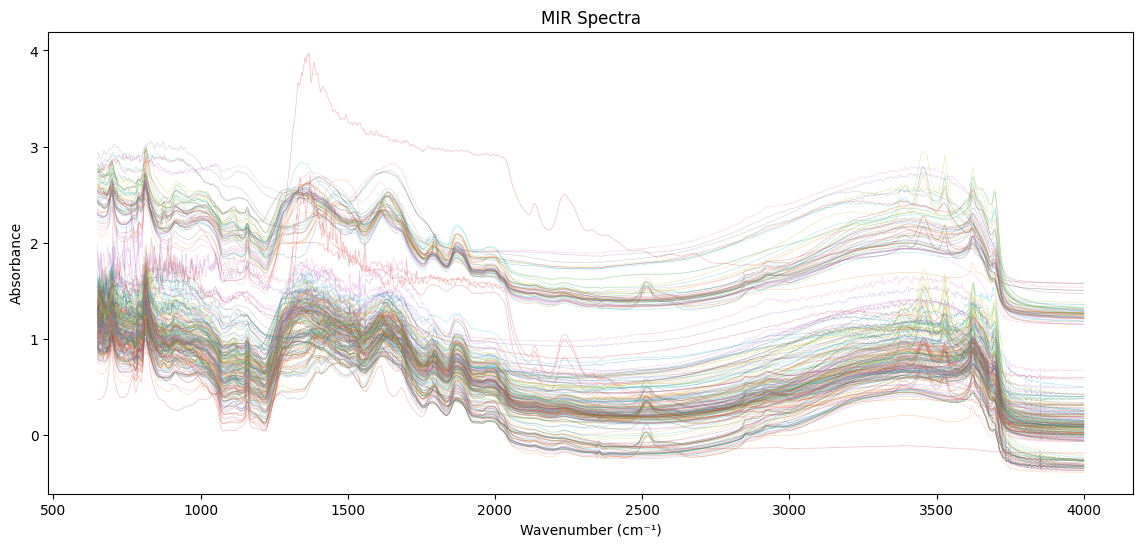

In [41]:
spectra = soil_spectroscopy[soil_spectroscopy.columns[3:]].values

plt.figure(figsize=(14, 6))
plt.plot(wavelengths, spectra.T, alpha=0.3, linewidth=0.5)

plt.xlabel('Wavenumber (cm⁻¹)')
plt.ylabel('Absorbance')
plt.title('MIR Spectra')
plt.show()

<p align="justify">
A sample is selected and its corresponding spectrum is extracted across the different instruments. The resulting curve displays the characteristic absorbance profile of that soil sample, with peaks and valleys representing the absorption bands of the different mineral and organic components present.
</p>

In [42]:
sample = soil_spectroscopy['sample_id'].unique()[3]
sample_data = soil_spectroscopy[soil_spectroscopy['sample_id'] == sample]

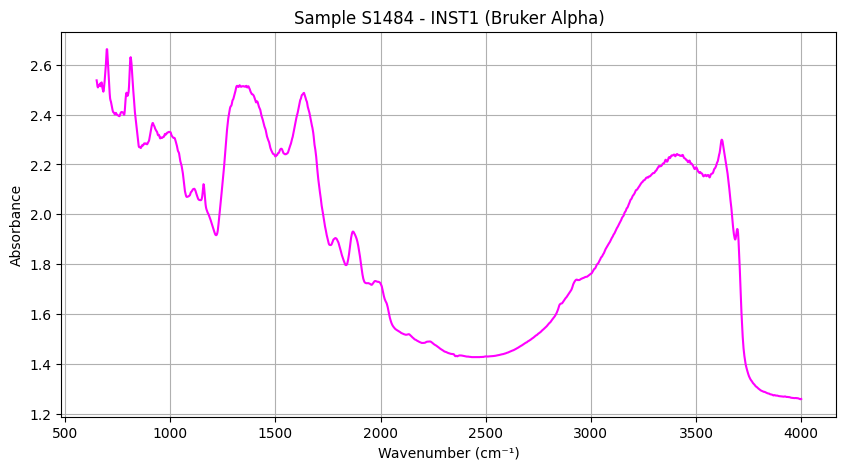

In [43]:
spectrum_inst1 = sample_data[
    sample_data['instrument'] == 'INST1'].to_numpy()[:, 3:][0]

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, spectrum_inst1, color="magenta")
plt.title(f"Sample {sample} - INST1 (Bruker Alpha)")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.grid(True)
plt.show()

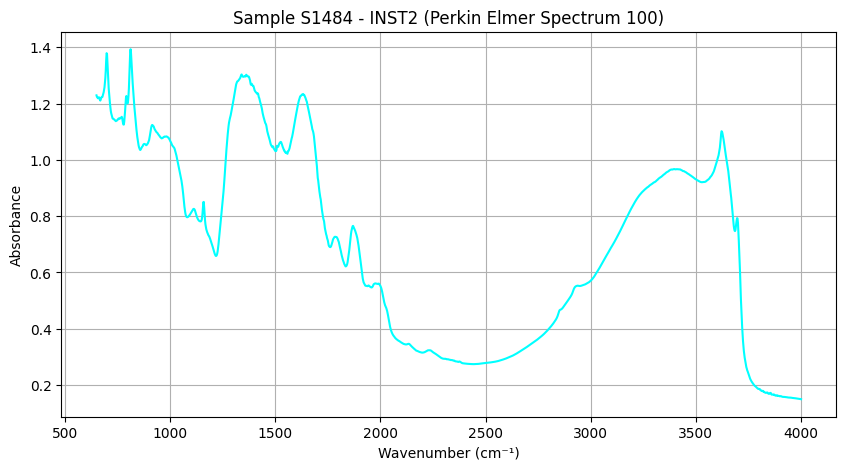

In [44]:
spectrum_inst2 = sample_data[
    sample_data['instrument'] == 'INST2'].to_numpy()[:, 3:][0]

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, spectrum_inst2, color="cyan")
plt.title(f"Sample {sample} - INST2 (Perkin Elmer Spectrum 100)")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.grid(True)
plt.show()

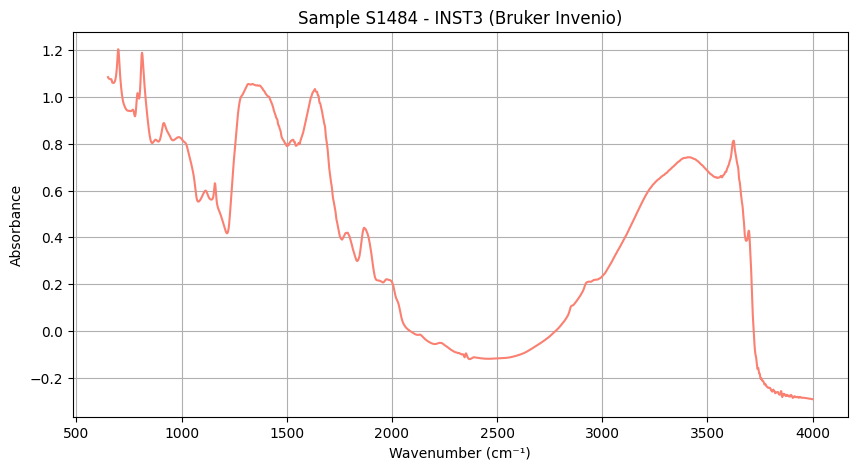

In [45]:
spectrum_inst3 = sample_data[
    sample_data['instrument'] == 'INST3'].to_numpy()[:, 3:][0]

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, spectrum_inst3, color="salmon")
plt.title(f"Sample {sample} - INST3 (Bruker Invenio)")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.grid(True)
plt.show()

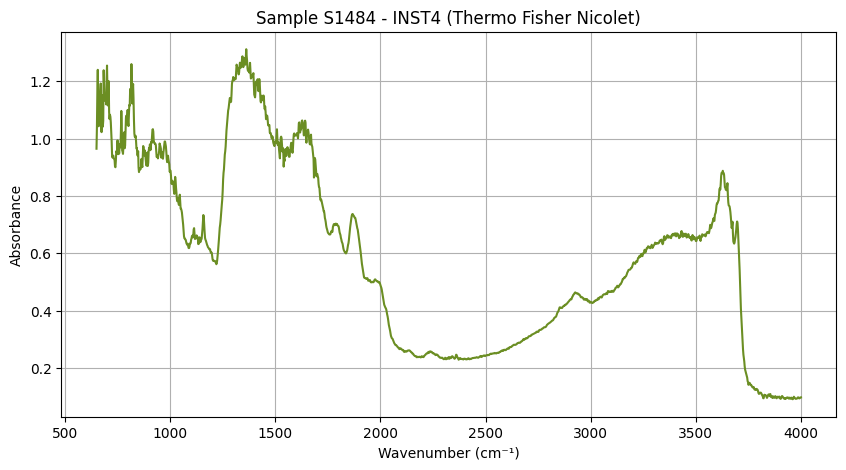

In [46]:
spectrum_inst4 = sample_data[
    sample_data['instrument'] == 'INST4'].to_numpy()[:, 3:][0]

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, spectrum_inst4, color="olivedrab")
plt.title(f"Sample {sample} - INST4 (Thermo Fisher Nicolet)")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.grid(True)
plt.show()

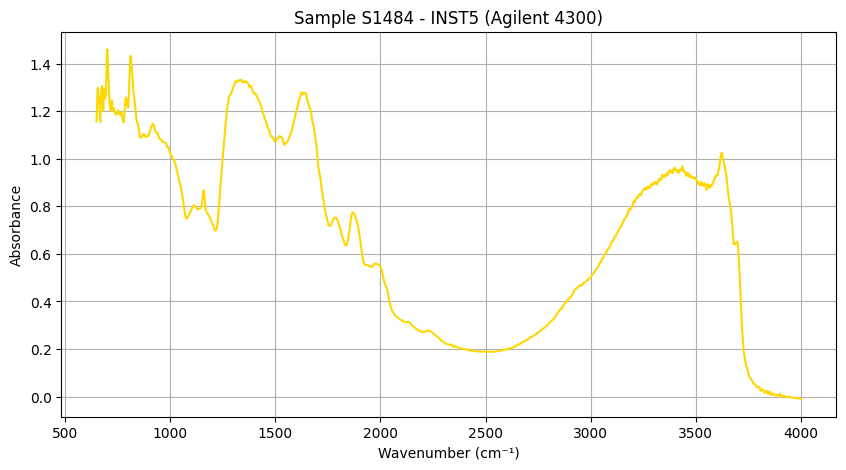

In [47]:
spectrum_inst5 = sample_data[
    sample_data['instrument'] == 'INST5'].to_numpy()[:, 3:][0]

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, spectrum_inst5, color="gold")
plt.title(f"Sample {sample} - INST5 (Agilent 4300)")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.grid(True)
plt.show()

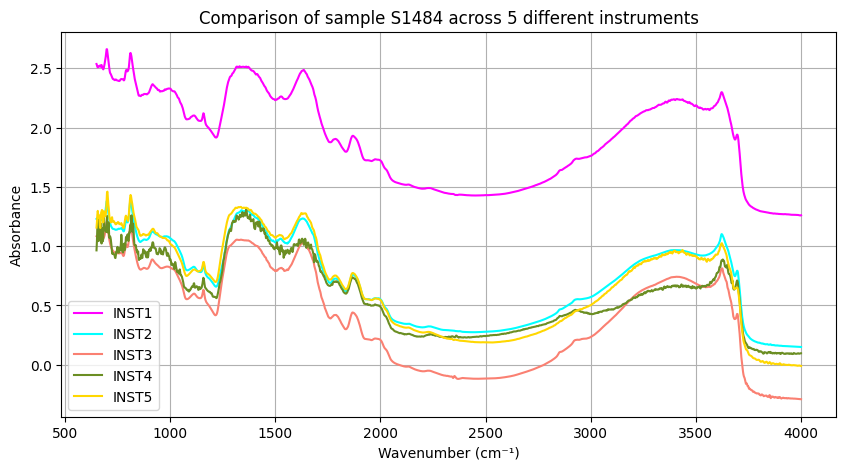

In [48]:
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, spectrum_inst1, color="magenta", label="INST1")
plt.plot(wavelengths, spectrum_inst2, color="cyan", label="INST2")
plt.plot(wavelengths, spectrum_inst3, color="salmon", label="INST3")
plt.plot(wavelengths, spectrum_inst4, color="olivedrab", label="INST4")
plt.plot(wavelengths, spectrum_inst5, color="gold", label="INST5")
plt.title(f"Comparison of sample {sample} across 5 different instruments")

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.legend()
plt.grid(True)
plt.show()

## 3.	OOP for data processing. 

<p align="justify">
The filtered DataFrame (sample_data) is converted to a numpy array, selecting all rows and columns from position 3 onwards (excluding unique_id, instrument, and sample_id). The result is a numpy matrix containing only the absorbance values of the 5 spectra corresponding to the selected sample, one per instrument.
</p>

In [49]:
sample_spectra = sample_data.to_numpy()[:, 3:].astype(float)
print(sample_spectra)
print(type(sample_spectra))

[[ 2.537    2.52715  2.51345 ...  1.25949  1.25956  1.26061]
 [ 1.22948  1.22418  1.22182 ...  0.15026  0.15004  0.14962]
 [ 1.08422  1.08018  1.0784  ... -0.29043 -0.29075 -0.29094]
 [ 0.96473  1.03998  1.16071 ...  0.09646  0.09657  0.09671]
 [ 1.1571   1.20174  1.26501 ... -0.00853 -0.00975 -0.01082]]
<class 'numpy.ndarray'>


<p align="justify">
The first method (without taking into account the constructor method) is moving average smoothing (moving_average). This is implemented because data acquired with spectrometers may exhibit noise, especially in certain spectral regions where peaks are generated due to the concentration of soil components. Smoothing enables more stable and comparable curves to be obtained without losing information from characteristic peaks.
</p>

<p align="justify">
The second method is area normalization (normalize_area), designed to enable direct comparison across all spectra. Consider a scenario where one sample exhibits a peak at 1000 cm⁻¹ with an intensity of 0.8, whereas another sample shows only 0.3 at the same wavenumber. Despite having similar spectral profiles, this amplitude disparity may suggest they differ significantly. By applying normalization, each spectrum is rescaled such that its total integrated area equals unity, thereby shifting the analytical focus toward spectral morphology (characteristic peaks and absorption bands) rather than absolute intensity values.
</p>

<p align="justify">
The third method calculates the area under the curve within specific ranges (calculate_band_area). This approach is implemented because certain spectral ranges have direct correlation with specific soil components. For example, the 1000–1200 cm⁻¹ range is associated with clay minerals (Si-O bonds), while the 1350–1450 cm⁻¹ range is related to organic matter (C-H bonds). Integrating the area under the curve within these intervals summarizes the spectral information into a single quantitative value enabling correlation of these values with the presence of edaphic components.
</p>

<p align="justify">
<strong>convolve:</strong> Smoothing is performed using a moving average filter with NumPy. A kernel is constructed and applied to each spectrum using convolve(), replacing each point with the average of its neighbors according to the selected window size. The 'same' parameter ensures that the resulting spectrum maintains the same number of points as the original.
</p>

<p align="justify">
<strong>trapezoid:</strong> Numerical integration is performed using NumPy's trapezoid function, which applies the trapezoidal rule. This operation calculates the area under the absorbance curve for each spectrum across the wavenumber range.
</p>

In [50]:
class SoilSpectraProcessor:

    def __init__(self, wavelengths, sample_spectra):
        self.wavelengths = wavelengths
        self.sample_spectra = sample_spectra

    def moving_average(self, window):
        kernel = np.ones(window) / window
        smoothed = np.array([
            np.convolve(row, kernel, mode="same") for row in self.sample_spectra])
        self.sample_spectra = smoothed
        return self

    def normalize_area(self):
        areas = np.trapezoid(self.sample_spectra, x=self.wavelengths, axis=1)
        for i in range(len(areas)):
            a = areas[i]
            if a == 0:
                a = 1e-9
            self.sample_spectra[i] = self.sample_spectra[i] / a
        return self

    def calculate_band_area(self, initial_cm, end_cm):
        mask = (self.wavelengths >= initial_cm) & (self.wavelengths <= end_cm)
        band_areas = np.trapezoid(self.sample_spectra[:, mask], x=self.wavelengths[mask], axis=1)
        return band_areas

In [51]:
spectra_processor = SoilSpectraProcessor(wavelengths, sample_spectra)

<p align="justify">
The figure shows a side-by-side comparison of the selected sample spectrum before and after applying the moving average smoothing method. The left panel presents the original spectrum with its characteristic variations and noise, while the right panel displays the same spectrum after processing with a smoothing window. It can be observed that the smoothed curve preserves the main absorption peaks and bands, but with a notable noise reduction, resulting in a cleaner spectral profile.
</p>

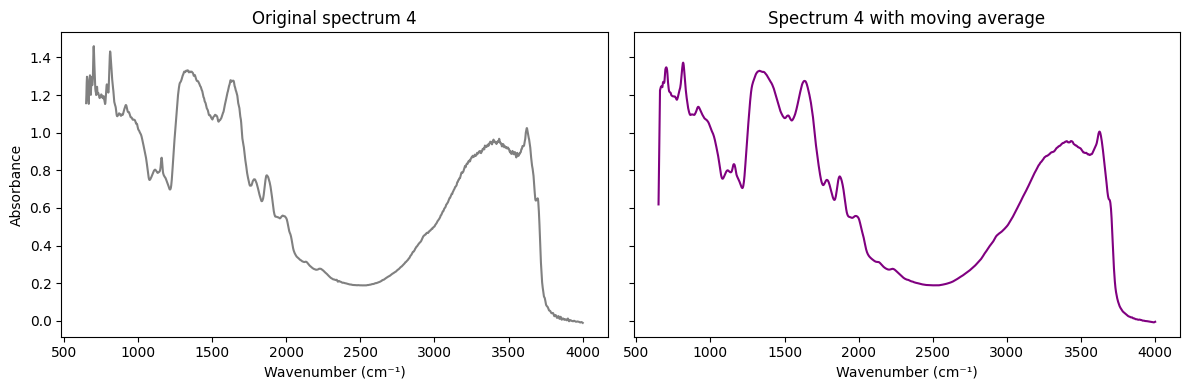

In [52]:
original_spectra = sample_spectra.copy()

spectra_processor.moving_average(window=10)

sample_idx = 4
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axs[0].plot(wavelengths, original_spectra[sample_idx], color="gray")
axs[0].set_title(f"Original spectrum {sample_idx}")
axs[0].set_xlabel("Wavenumber (cm⁻¹)")
axs[0].set_ylabel("Absorbance")

axs[1].plot(wavelengths, spectra_processor.sample_spectra[sample_idx], color="purple")
axs[1].set_title(f"Spectrum {sample_idx} with moving average")
axs[1].set_xlabel("Wavenumber (cm⁻¹)")

plt.tight_layout()
plt.show()

<p align="justify">
The figure presents a comparison between the original spectrum of the selected sample and its area-normalized version. The left panel displays the spectrum with its original absorbance values (approximate range of -0.2 to 1.2), while the right panel shows the spectrum after normalization, where the values have been scaled to a total area of 1 (approximate range of -0.0002 to 0.0010). It can be observed that the spectral shape is preserved, maintaining the same absorption peaks and bands, but with a different scale that enables direct comparisons between samples regardless of their original magnitudes.
</p>

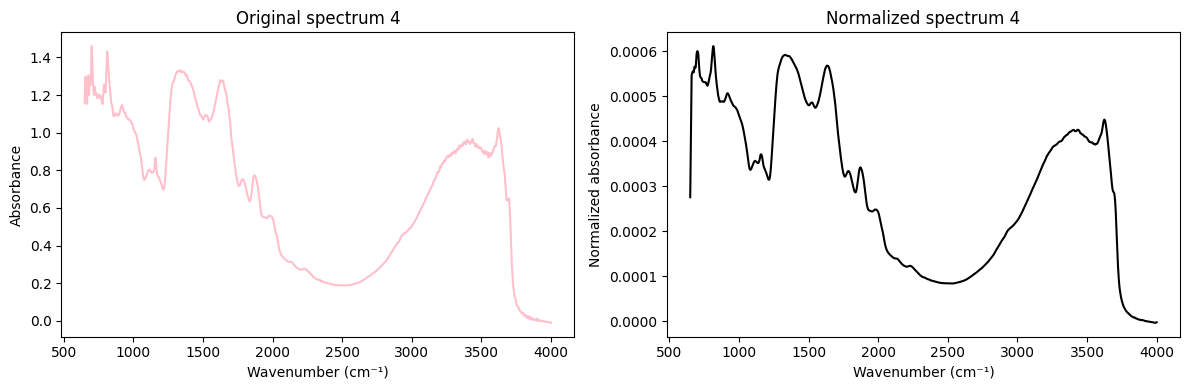

In [53]:
spectra_processor.normalize_area()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(wavelengths, original_spectra[sample_idx], color="pink")
axs[0].set_title(f"Original spectrum {sample_idx}")
axs[0].set_xlabel("Wavenumber (cm⁻¹)")
axs[0].set_ylabel("Absorbance")

axs[1].plot(wavelengths, spectra_processor.sample_spectra[sample_idx], color="black")
axs[1].set_title(f"Normalized spectrum {sample_idx}")
axs[1].set_xlabel("Wavenumber (cm⁻¹)")
axs[1].set_ylabel("Normalized absorbance")

plt.tight_layout()
plt.show()

<p align="justify">
The figure illustrates the normalized spectrum of the sample with two spectral regions highlighted through shading. The blue region (1000–1200 cm⁻¹) corresponds to absorption bands associated with clay minerals (Si-O bonds), with a calculated area of 0.1087. The red region (1350–1450 cm⁻¹) represents bands related to organic matter (C-H bonds), with an area of 0.0614.
</p>

Area under the curve from 1000 to 1200 cm⁻¹: 0.0744520007269867
Area under the curve from 1350 to 1450 cm⁻¹: 0.05660133959760119


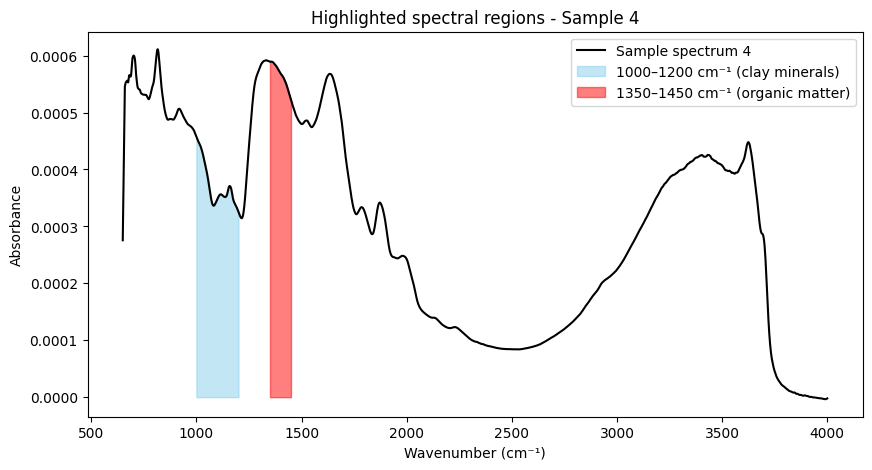

In [54]:
band_area_one = spectra_processor.calculate_band_area(1000, 1200)[sample_idx]
band_area_two = spectra_processor.calculate_band_area(1350, 1450)[sample_idx]
print(f"Area under the curve from 1000 to 1200 cm⁻¹: {band_area_one}")
print(f"Area under the curve from 1350 to 1450 cm⁻¹: {band_area_two}")

clay_minerals_range = (wavelengths >= 1000) & (wavelengths <= 1200)
organic_matter_range = (wavelengths >= 1350) & (wavelengths <= 1450)

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, spectra_processor.sample_spectra[sample_idx], 
         color="black", label=f"Sample spectrum {sample_idx}")
plt.fill_between(wavelengths[clay_minerals_range], spectra_processor.sample_spectra[sample_idx][clay_minerals_range],
                 color="skyblue", alpha=0.5, 
                 label="1000–1200 cm⁻¹ (clay minerals)")
plt.fill_between(wavelengths[organic_matter_range], spectra_processor.sample_spectra[sample_idx][organic_matter_range],
                 color="red", alpha=0.5, 
                 label="1350–1450 cm⁻¹ (organic matter)")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.title(f"Highlighted spectral regions - Sample {sample_idx}")
plt.legend()
plt.show()

## 4.	Numerical derivation or integration of data. 

<p align="justify">
In this analysis, a soil spectroscopy dataset was used to calculate the derivative of the absorbance spectrum with respect to wavenumber. The purpose is to identify signal maximum and minimum with greater precision, which correspond to spectral peaks and valleys. This technique enables detection of the most abrupt changes in the curve slope, facilitating exact localization of absorption bands. In this way, wavenumber ranges linked to different mineral and organic soil components can be identified.
</p>

<p align="justify">
To convert the discrete spectral data into a continuous function, a function is defined that employs np.interp to perform linear interpolation between wavenumber and absorbance values, allowing estimation of values at unmeasured intermediate points. Fixed values were also assigned at the spectrum endpoints so that, when evaluating outside the original range, the nearest boundary value is returned, preventing extrapolation errors.
</p>

In [65]:
class ForwardDerivative:
    def __init__(self, func, h=2):
        self.f = func
        self.h = h
    
    def __call__(self, x):
        return (self.f(x + self.h) - self.f(x)) / self.h


class CentralDerivative(ForwardDerivative):
    def __call__(self, x):
        return (self.f(x + self.h) - self.f(x - self.h)) / (2 * self.h)

In [70]:
def func_spectrum(x):
    return np.interp(x, wavelengths, original_spectra[sample_idx], 
                     left=original_spectra[sample_idx][0], 
                     right=original_spectra[sample_idx][-1])

<p align="justify">
The increment value h was defined using the actual measurement step of 2 cm⁻¹. Subsequently, an instance of the CentralDerivative class was created using the spectral function func_spectrum along with the step h. Finally, the derivative was evaluated at each point of the wavenumber vector, yielding the derivative_absorbance array as a result. This array contains the absorbance variation with respect to wavenumber for each position in the spectrum.
</p>

In [71]:
h = np.mean(np.diff(wavelengths))
df = CentralDerivative(func_spectrum, h=h)
derivative_absorbance = df(wavelengths)

<p align="justify">
The presented vector contains the numerical derivative values of absorbance with respect to wavenumber for the sample. Each value represents the spectrum slope: positive numbers indicate an increase in absorbance, negative values reflect a decrease, and values close to zero correspond to stable regions without significant changes.
</p>

The numerical derivative values for sample 4 are: [ 0.01116    0.0269775  0.0239875 ... -0.0005875 -0.0005725 -0.0002675]


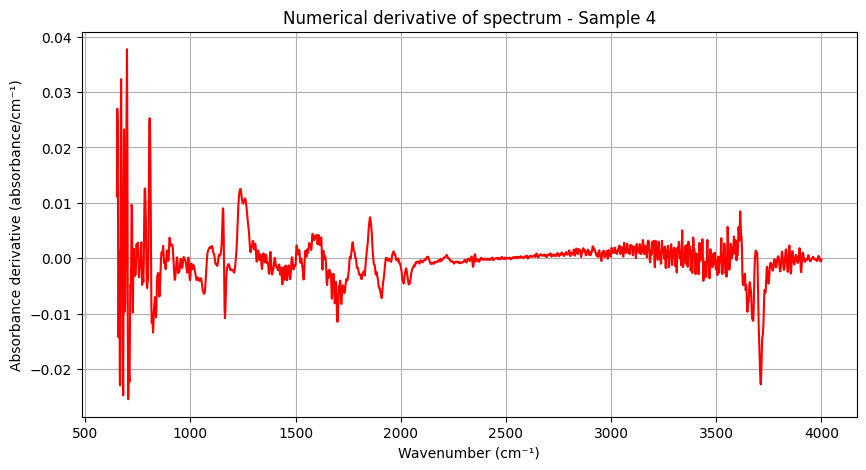

In [73]:
print(f"The numerical derivative values for sample {
    sample_idx} are: {derivative_absorbance}")

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, derivative_absorbance, color="red")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance derivative (absorbance/cm⁻¹)")
plt.title(f"Numerical derivative of spectrum - Sample {sample_idx}")
plt.grid(True)
plt.show()

<p align="justify">
These variations are visualized in the plot. It can be observed that the most abrupt changes occur in the region between 500 and 1500 cm⁻¹, which may correspond to the absorption bands of clay minerals and organic matter previously identified. As the wavenumber increases toward the 2000–3500 cm⁻¹ region, the derivative tends to stabilize near zero, indicating that the spectral signal becomes more uniform and lacks marked variations. In the 3500–4000 cm⁻¹ region, pronounced changes are observed again, suggesting the presence of absorption bands associated with specific soil functional groups.
</p>

## 5.	Matrix operations. 

In [74]:
print(type(wavelengths))
print(type(sample_spectra))
print(f'The following vector shows the wavelengths are:\n {wavelengths}')
print(f'\nThe following matrix shows the absorbance values: {sample_spectra}')
print(sample_spectra.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
The following vector shows the wavelengths are:
 [ 650.  652.  654. ... 3996. 3998. 4000.]

The following matrix shows the absorbance values: [[ 2.537    2.52715  2.51345 ...  1.25949  1.25956  1.26061]
 [ 1.22948  1.22418  1.22182 ...  0.15026  0.15004  0.14962]
 [ 1.08422  1.08018  1.0784  ... -0.29043 -0.29075 -0.29094]
 [ 0.96473  1.03998  1.16071 ...  0.09646  0.09657  0.09671]
 [ 1.1571   1.20174  1.26501 ... -0.00853 -0.00975 -0.01082]]
(5, 1676)


**Spectral matrix extraction within a specific range:**

<p align="justify">
First, it is verified whether the dimensions of the spectra array match the wavenumber vector. If they do not match, the matrix is transposed to correctly align rows and columns; otherwise, the original matrix is retained. Subsequently, a boolean mask is created to select only the wavenumbers within the 1000–1500 cm⁻¹ range. This mask is applied to the absorbance matrix to extract only the columns corresponding to that spectral interval, storing the result in extract_soilwave. Finally, the size of the extracted matrix and its first 5 values are printed to verify the operation.
</p>

In [ ]:
if sample_spectra.shape[0] != wavelengths.shape[0]:
    absorbance_matrix = sample_spectra.T
else:
    absorbance_matrix = sample_spectra

mask = (wavelengths >= 1000) & (wavelengths <= 1500)
extract_soilwave = absorbance_matrix[mask, :]

print("Extracted matrix size in the 1000-1500 cm⁻¹ range:", extract_soilwave.shape)
print("First 5 values of the extracted matrix:\n", extract_soilwave[:5, :5])

Extracted matrix size in the 1000-1500 cm⁻¹ range: (251, 5)
First 5 values of the extracted matrix:
 [[2.3299  1.06794 0.81998 0.88799 1.02221]
 [2.32841 1.06462 0.81759 0.88817 1.01718]
 [2.32282 1.06274 0.81517 0.87131 1.01486]
 [2.3171  1.05942 0.81286 0.84497 1.01341]
 [2.31392 1.05522 0.81083 0.84159 1.01018]]


<p align="justify">
The Hadamard product multiplies two matrices or vectors element-wise, producing a result with the same dimensions as the operands. Unlike the dot product, it does not sum the results. This operation is useful for applying masks or weights to spectra, enabling specific spectral regions to be emphasized or attenuated according to the values of the second vector.
</p>

In [85]:
spectrum_1 = extract_soilwave[:, 0]
spectrum_2 = extract_soilwave[:, 1]
hadamard_product = spectrum_1 * spectrum_2

print(f"Hadamard product: {hadamard_product.shape}")
print(f"First 10 values: {np.round(hadamard_product[:10], 4)}")

Hadamard product: (251,)
First 10 values: [2.4882 2.4789 2.4686 2.4548 2.4417 2.431  2.4245 2.4192 2.4131 2.4087]


<p align="justify">
First, broadcasting is applied between the spectra matrix (251, 5) and a weight vector (5,). NumPy automatically expands the vector to multiply each row of the matrix element-wise, generating a weighted matrix of the same dimensions. The weights allow assigning greater or lesser importance to certain samples. Then, the matrix product of the transpose by itself is performed, obtaining a weighted covariance matrix (5, 5) that reflects the relationships between samples considering the assigned weights.
</p>

In [88]:
matrix_A = extract_soilwave[:, :5]
weights = np.array([0.5, 1.0, 1.5, 1.0, 0.5])

weighted_matrix = matrix_A * weights

matrix_product = weighted_matrix.T @ weighted_matrix

print(f"Matrix A: {matrix_A.shape}")
print(f"Weight vector: {weights.shape}")
print(f"Weighted matrix (broadcasting): {weighted_matrix.shape}")
print(f"Matrix product: {matrix_product.shape}")
print(f"Result:\n{np.round(matrix_product, 4)}")

Matrix A: (251, 5)
Weight vector: (5,)
Weighted matrix (broadcasting): (251, 5)
Matrix product: (5, 5)
Result:
[[320.5648 288.8837 339.8473 264.4983 148.1051]
 [288.8837 264.221  312.7527 243.6113 135.4963]
 [339.8473 312.7527 371.9973 289.629  160.7212]
 [264.4983 243.6113 289.629  226.0359 125.2596]
 [148.1051 135.4963 160.7212 125.2596  69.6639]]


## Discussion section and conclusions 

### Conclusions

## References
Bünemann, E. K., Bongiorno, G., Bai, Z., Creamer, R. E., De Deyn, G., de Goede, R., Fleskens, L., Geissen, V., Kuyper, T. W., Mäder, P., Pulleman, M., Sukkel, W., van Groenigen, J. W., & Brussaard, L. (2018). Soil quality – A critical review. Soil Biology and Biochemistry, 120, 105–125. https://doi.org/10.1016/j.soilbio.2018.01.030

Calderón, F. J., et al. (2022). Mid-infrared spectroscopy for accurate measurement of an extensive set of soil properties for assessing soil functions. Soil Security, 6, 100043. https://doi.org/10.1016/j.soisec.2022.100043

Doran, J. W., & Zeiss, M. R. (2000). Soil health and sustainability: managing the biotic component of soil quality. Applied Soil Ecology, 15(1), 3–11. https://doi.org/10.1016/S0929-1393(00)00067-6

Guo, M. (2021). Soil Health Assessment and Management: Recent Development in Science and Practices. Soil Systems, 5(4), 61. https://doi.org/10.3390/soilsystems5040061

Hengl, T., et al. (2021). African soil properties and nutrients mapped at 30 m spatial resolution using two-scale ensemble machine learning. Scientific Reports, 11, 6130. https://doi.org/10.1038/s41598-021-85639-y

Janik, L. J., Skjemstad, J. O., Shepherd, K. D., & Spouncer, L. R. (2007). The prediction of soil carbon fractions using mid-infrared-partial least square analysis. Australian Journal of Soil Research, 45(2), 73–81. https://doi.org/10.1071/SR06083

Lehmann, J., Bossio, D. A., Kögel-Knabner, I., & Rillig, M. C. (2020). The concept and future prospects of soil health. Nature Reviews Earth & Environment, 1(10), 544–553. https://doi.org/10.1038/s43017-020-0080-8

Liu, J., et al. (2020). Soil Moisture Estimate Uncertainties from the Effect of Soil Texture on Dielectric Semiempirical Models. Remote Sensing, 12(14), 2343. https://doi.org/10.3390/rs12142343

Liu, W., Baret, F., Gu, X., Tong, Q., Zheng, L., & Zhang, B. (2002). Relating soil surface moisture to reflectance. Remote Sensing of Environment, 81(2-3), 238–246. https://doi.org/10.1016/S0034-4257(01)00347-9

Norris, C. E., Bean, G. M., Cappellazzi, S. B., Cope, M., Greub, K. L. H., Liptzin, D., Rieke, E. L., Tracy, P. W., Morgan, C. L. S., & Honeycutt, C. W. (2020). Introducing the North American project to evaluate soil health measurements. Agronomy Journal, 112(4), 3195–3215. https://doi.org/10.1002/agj2.20234

Orgiazzi, A., Ballabio, C., Panagos, P., Jones, A., & Fernández-Ugalde, O. (2018). LUCAS Soil, the largest expandable soil dataset for Europe: a review. European Journal of Soil Science, 69(1), 140–153. https://doi.org/10.1111/ejss.12499

Reeves, J. B. (2010). Near- versus mid-infrared diffuse reflectance spectroscopy for soil analysis emphasizing carbon and laboratory versus on-site analysis. Geoderma, 158(1-2), 3–14. https://doi.org/10.1016/j.geoderma.2009.04.005

Roberts, J. J., & Cozzolino, D. (2016). Wet or dry? The effect of sample characteristics on near infrared spectroscopy of soils. TrAC Trends in Analytical Chemistry, 83, 25–30. https://doi.org/10.1016/j.trac.2016.08.002

Safanelli, J. L., et al. (2025). Open Soil Spectral Library (OSSL): Building reproducible soil calibration models. PLoS ONE, 20(1), e0296545. https://doi.org/10.1371/journal.pone.0296545

Soriano-Disla, J. M., Janik, L. J., Viscarra Rossel, R. A., Macdonald, L. M., & McLaughlin, M. J. (2014). The Performance of Visible, Near-, and Mid-Infrared Reflectance Spectroscopy for Prediction of Soil Physical, Chemical, and Biological Properties. Applied Spectroscopy Reviews, 49(2), 139–186. https://doi.org/10.1080/05704928.2013.811081

Stenberg, B., Viscarra Rossel, R. A., Mouazen, A. M., & Wetterlind, J. (2010). Visible and Near Infrared Spectroscopy in Soil Science. Advances in Agronomy, 107, 163–215. https://doi.org/10.1016/S0065-2113(10)07005-7

Tóth, G., Jones, A., & Montanarella, L. (2013). The LUCAS topsoil database and derived information on the regional variability of cropland topsoil properties in the European Union. Environmental Monitoring and Assessment, 185(9), 7409–7425. https://doi.org/10.1007/s10661-013-3109-3

Viscarra Rossel, R. A., & McBratney, A. B. (2010). Diffuse Reflectance Spectroscopy for High-Resolution Soil Sensing. In Proximal Soil Sensing (pp. 29–47). Springer. https://doi.org/10.1007/978-90-481-8859-8_3

Viscarra Rossel, R. A., et al. (2022). A global soil spectral calibration library and estimation service. Soil Security, 7, 100061. https://doi.org/10.1016/j.soisec.2022.100061

Zeng, Y., Verhoef, A., Vereecken, H., Ben-Dor, E., Veldkamp, T., Shaw, L., Wang, Y., & Su, Z. B. (2024). Tracking Soil Health: Monitoring and Modeling the Soil-Plant System. Authorea Preprints. https://doi.org/10.22541/essoar.171804479.91646868/v1